In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/canonical-rbc-dns-c0r0/info.json
/kaggle/input/canonical-rbc-dns-c0r0/grid/Y_m.dat
/kaggle/input/canonical-rbc-dns-c0r0/grid/X_m.dat
/kaggle/input/canonical-rbc-dns-c0r0/grid/Z_m.dat
/kaggle/input/canonical-rbc-dns-c0r0/data/T_id001.dat
/kaggle/input/canonical-rbc-dns-c0r0/data/UZ_id000.dat
/kaggle/input/canonical-rbc-dns-c0r0/data/UX_id001.dat
/kaggle/input/canonical-rbc-dns-c0r0/data/UY_id000.dat
/kaggle/input/canonical-rbc-dns-c0r0/data/P_id001.dat
/kaggle/input/canonical-rbc-dns-c0r0/data/UX_id000.dat
/kaggle/input/canonical-rbc-dns-c0r0/data/UY_id001.dat
/kaggle/input/canonical-rbc-dns-c0r0/data/P_id000.dat
/kaggle/input/canonical-rbc-dns-c0r0/data/T_id000.dat
/kaggle/input/canonical-rbc-dns-c0r0/data/UZ_id001.dat


In [3]:
import numpy as np # linear algebra
import json
import os
import matplotlib.pyplot as plt

data_path = '/kaggle/input/'+os.popen('ls '+'/kaggle/input/').read().split('\n')[0]+'/'
print("Data path: ",data_path)

Data path:  /kaggle/input/canonical-rbc-dns-c0r0/


In [4]:
f = open(data_path + '/info.json')
metadata = json.load(f) #returns a dict

In [5]:
for key in metadata['global']:
    print(key," : ",metadata['global'][key])

dataset_id  :  blastnet/canonical-rbc-dns-c0r0
Nxyz  :  [2049, 2049, 1025]
snapshots  :  2
variables  :  ['UX', 'UY', 'UZ', 'P', 'T']
compression  :  None
grid  :  {'x': './grid/X_m.dat', 'y': './grid/Y_m.dat', 'z': './grid/Z_m.dat'}
bc  :  Periodic in x-, y-directions, bounded by no-slip walls along z-direction.
ic  :  Natural thermal convection in a cuboidal box of aspect ratio 4 at fixed Prandtl number = 0.7 and Rayleigh number = 1.00E+05 with nu = 0.00264575131 and kappa = 0.00377964473. 
description  :  DNS of Rayleigh Benard convection at moderate to high Rayleigh numbers. All the variables reported in this dataset are in the dimensionless form. For more information about the normalization, we refer the user to the dataset webpage on BLASTNet.
doi  :  https://doi.org/10.1017/jfm.2024.853
contributors  :  Roshan Samuel, Mathis Bode


In [6]:
if len(metadata['local'])>3:
    for file_id in range(3):
        for key in metadata['local'][file_id]:
            print(key," : ",metadata['local'][file_id][key])
        print("----------------------------------")
else:
    file_id = 0
    for key in metadata['local'][file_id]:
        print(key," : ",metadata['local'][file_id][key])

id  :  0
time  :  3550
UX filename  :  ./data/UX_id000.dat
UY filename  :  ./data/UY_id000.dat
UZ filename  :  ./data/UZ_id000.dat
P filename  :  ./data/P_id000.dat
T filename  :  ./data/T_id000.dat


In [7]:
Nx,Ny,Nz = metadata['global']['Nxyz']

X_filename = metadata['global']['grid']['x']
Y_filename = metadata['global']['grid']['y']
Z_filename = metadata['global']['grid']['z']

print(X_filename)
print(Y_filename)
print(Z_filename)

./grid/X_m.dat
./grid/Y_m.dat
./grid/Z_m.dat


In [9]:
#load data
X =  np.fromfile(data_path+X_filename,dtype='<f4')
Y =  np.fromfile(data_path+Y_filename,dtype='<f4')
Z =  np.fromfile(data_path+Z_filename,dtype='<f4')

#get 1d profile
x1d = np.unique(X)
y1d = np.unique(Y)
z1d = np.unique(Z)

Text(0.5, 0, 'Index k')

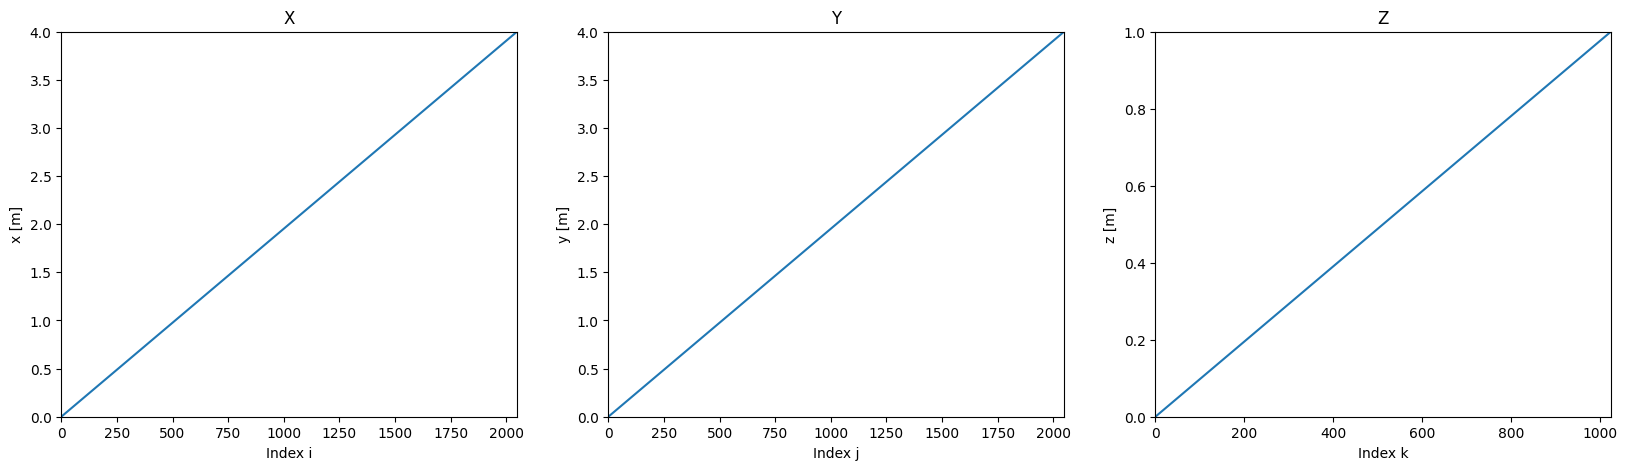

In [10]:
fig, axs = plt.subplots(1,3,figsize=(20, 5))
axs[0].plot(x1d)
axs[0].set_xlim([0,len(x1d)])
axs[0].set_ylim([x1d.min(),x1d.max()])
axs[0].set_title('X')
axs[0].set_ylabel('x [m]')
axs[0].set_xlabel('Index i')


axs[1].plot(y1d)
axs[1].set_xlim([0,len(y1d)])
axs[1].set_ylim([y1d.min(),y1d.max()])
axs[1].set_title('Y')
axs[1].set_ylabel('y [m]')
axs[1].set_xlabel('Index j')

axs[2].plot(z1d)
axs[2].set_xlim([0,len(z1d)])
axs[2].set_ylim([z1d.min(),z1d.max()])
axs[2].set_title('Z')
axs[2].set_ylabel('z [m]')
axs[2].set_xlabel('Index k')

In [11]:
#Random number generator
nfile = len(metadata['local'])
file_id = np.random.randint(nfile)

#Load and reshape array
u_filename = metadata['local'][file_id]['UX filename']
u = np.fromfile(data_path+u_filename,dtype='<f4')
u = u.reshape(Nx,Ny,Nz)

print("Array shape: ")
print(u.shape)

Array shape: 
(2049, 2049, 1025)


File Id = 1
t = unknown s


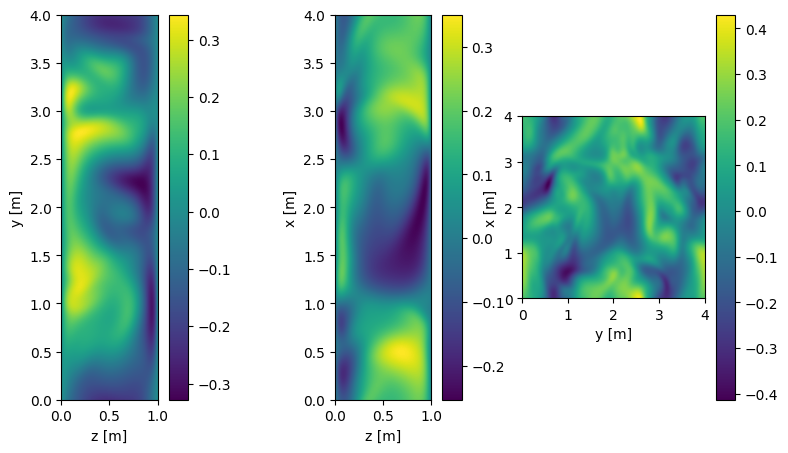

In [11]:
align='horizontal'
figsize = np.array((10, 5))
if align == 'vertical':
    fig, axs = plt.subplots(3,1,figsize=figsize.T)

    imX = axs[0].imshow(u[int(len(x1d)/2),:,:].T,origin='lower',extent = [y1d.min(), y1d.max(),z1d.min(),z1d.max()])
    axs[0].set_xlabel('y [m]')
    axs[0].set_ylabel('z [m]')

    imY = axs[1].imshow(u[:,int(len(y1d)/2),:].T,origin='lower',extent = [x1d.min(), x1d.max(),z1d.min(),z1d.max()])
    axs[1].set_xlabel('x [m]')
    axs[1].set_ylabel('z [m]')

    imZ = axs[2].imshow(u[:,:,int(len(z1d)/2)].T,origin='lower',extent = [x1d.min(), x1d.max(),y1d.min(),y1d.max()])
    axs[2].set_xlabel('x [m]')
    axs[2].set_ylabel('y [m]')
else:
    fig, axs = plt.subplots(1,3,figsize=figsize)
    imX = axs[0].imshow(u[int(len(x1d)/2),:,:],origin='lower',extent = [z1d.min(),z1d.max(),y1d.min(), y1d.max()])
    axs[0].set_ylabel('y [m]')
    axs[0].set_xlabel('z [m]')

    imY = axs[1].imshow(u[:,int(len(y1d)/2),:],origin='lower',extent = [z1d.min(),z1d.max(),x1d.min(), x1d.max()])
    axs[1].set_ylabel('x [m]')
    axs[1].set_xlabel('z [m]')

    imZ = axs[2].imshow(u[:,:,int(len(z1d)/2)],origin='lower',extent = [y1d.min(),y1d.max(),x1d.min(), x1d.max()])
    axs[2].set_ylabel('x [m]')
    axs[2].set_xlabel('y [m]')

plt.colorbar(imX, ax=axs[0])
plt.colorbar(imY, ax=axs[1])
plt.colorbar(imZ, ax=axs[2])

print('File Id = '+str(metadata['local'][file_id]['id']))
print('t = ' + str(metadata['local'][file_id].get('time [s]', 'unknown')) + ' s')
